## NFA

NFA= #C * $P_ {h0}(K(d)>k(d))$  
K(d)=k(d) variable aleatoire de k(d)  
X=[r+1,$N_1$-r-1]  
$N_1$ periode du spectre  
k(d)=$\sum_{P_i}$ $1_{\\{ρ(P_i,d)=maxN_r  (P_i,d)\\}}$    
$N_r(P_i,d)=\{ρ(P_i, d′) : d′ ∈ [[d−r, +r]]\}$ 
$ρ(P_i,d)=corr(P_i,Q_i)$



In [11]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.stats import binom


In [12]:
def ranktransform(x):
    """
    Rank transform of the image input x
    Computes the rank of the intensity of each pixel x in its 7x7 neighborhood
    """
    image = x.astype(np.float32)

    # Traitement des problèmes de bord
    pad = 3 # 7 // 2
    padded = np.pad(image, pad, mode='reflect')

    H, W = image.shape
    rtImage = np.zeros((H, W), dtype=np.float32)
    for x in range(-pad, pad + 1):
        for y in range(-pad, pad + 1):
            if y == 0 and x == 0:  #pixel central
                continue
            neighbor = padded[pad + y: pad + y + H, pad + x: pad + x + W]
            rtImage += (neighbor < image).astype(np.float32)
 
    return rtImage


Distances détectées :

X_min=5, X_max=500
format image : (512, 512)


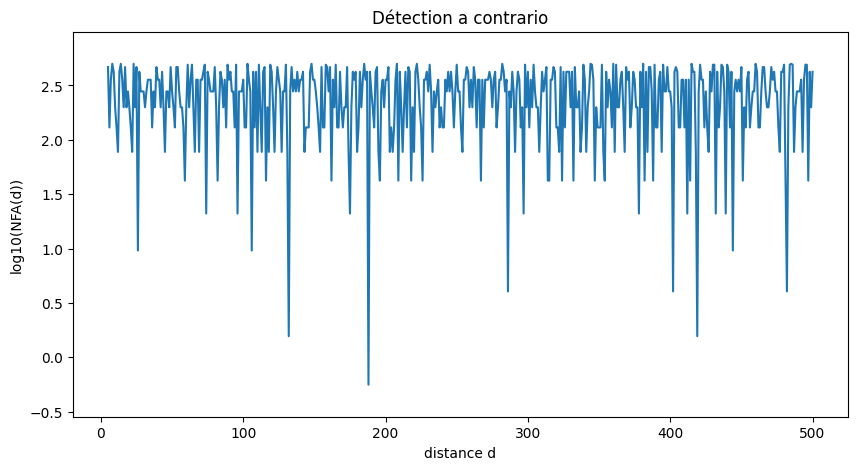

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.stats import binom

PATCH_SIZE = 8
R = 4
DMAX = 500
EPSILON = 0.01
step = PATCH_SIZE

img = cv2.imread("/home/julesaout2003/informarctique/2A/IMA/S2/modèle_generatif/Projet/IM206/IMG_InPut/babbon.png", cv2.IMREAD_GRAYSCALE)
if img is None:
    raise ValueError("Image introuvable")



h, w = img.shape
img = cv2.resize(img, (int(w*1.3), int(h*1.3)), interpolation=cv2.INTER_NEAREST)
#img = cv2.resize(img, (w, h), interpolation=cv2.INTER_NEAREST)
img = img.astype(np.float32)
img = ranktransform(img)
F = np.fft.fft2(img)
S=F

N0, N1 = S.shape

X_min = R + 1
X_max = min(DMAX, N1 - R - 1)
C = N1 - 2 * R - 1

def correlation(Pi, Qi):
    Pi = Pi - np.mean(Pi)
    Qi = Qi - np.mean(Qi)
    num = np.abs(np.dot(Pi, np.conj(Qi)))
    den = np.linalg.norm(Pi) * np.linalg.norm(Qi) + 1e-8
    return num / den

patches_y_max = N0 - PATCH_SIZE
patches_x_max = N1 - PATCH_SIZE - X_max

nb_patch = len(range(0, patches_y_max, step)) * len(range(0, patches_x_max, step))

k = np.zeros(X_max + 1)
rho_len = (X_max + R) - (X_min - R) + 1
all_is_max = []

for y in range(0, patches_y_max, step):
    for x in range(0, patches_x_max, step):
        Pi = S[y:y + PATCH_SIZE, x:x + PATCH_SIZE].flatten()
        rho = np.zeros(rho_len)
        for d in range(X_min - R, X_max + R + 1):
            Qi = S[y:y + PATCH_SIZE, x + d:x + d + PATCH_SIZE].flatten()
            rho[d - (X_min - R)] = correlation(Pi, Qi)
        for d in range(X_min, X_max + 1):
            i = d - (X_min - R)
            Nr = rho[i - R: i + R + 1]
            is_max = int(rho[i] == np.max(Nr))
            all_is_max.append(is_max)
            k[d] += is_max

p = np.mean(all_is_max)
"""
print(f"nb_patch = {nb_patch}")
print(f"C = {C}")
print(f"p empirique = {p:.4f}  (théorique = {1/(2*R+1):.4f})")
print(f"k max = {np.max(k[X_min:X_max+1]):.0f}")
print(f"k mean = {np.mean(k[X_min:X_max+1]):.2f}")
print(f"E[k] sous H0 = {nb_patch * p:.2f}")"""

NFA = np.zeros(X_max + 1)
for d in range(X_min, X_max + 1):
    proba = binom.sf(int(k[d]) - 1, nb_patch, p)
    NFA[d] = C * proba
"""for d in range(X_min, X_max+1):
    print(f"d={d:3d} | k={k[d]:.0f} | E[k]={nb_patch*p:.1f} | diff={k[d]-nb_patch*p:+.1f}")
print(f"NFA min = {np.min(NFA[X_min:X_max+1]):.3e}")"""
print("\nDistances détectées :\n")
for d in range(X_min, X_max + 1):
    if NFA[d] < EPSILON:
        print(f"d={d:3d} | k(d)={k[d]:8.0f} | NFA={NFA[d]:.3e}")
print(f"X_min={X_min}, X_max={X_max}")
print(f"format image : {img.shape}")

"""plt.imshow(np.log(1 + np.abs(F)), cmap='gray')
plt.colorbar()
plt.title("Spectre log")
plt.show()"""
data = np.log10(NFA[X_min:X_max + 1])
y_min, y_max = data.min(), data.max()
margin = (y_max - y_min) * 0.1

plt.figure(figsize=(10, 5))
plt.plot(range(X_min, X_max + 1), data)
plt.ylim(y_min - margin, y_max + margin)
plt.xlabel("distance d")
plt.ylabel("log10(NFA(d))")
plt.title("Détection a contrario")
plt.show()